In [1]:
from models.qnet import QCNet

arch = QCNet

In [2]:
classes = range(2)

In [3]:
def num_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return n

In [4]:
print(f"{arch(len(classes)).__class__.__name__} has {num_params(arch(len(classes)))} parameters")

QCNet has 44473 parameters


In [5]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import numpy as np

In [6]:
manualSeed = 999
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

In [7]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,), (0.5,))])

batch_size = 1
n_train = 100  # We will concentrate on the first 100 samples
n_valid = 400

# Use pre-defined torchvision function to load MNIST train data
X_train = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

# Filter out labels (originally 0-9), leaving only labels 0 and 1
idx = np.concatenate(
    [np.where(X_train.targets == c)[0][:n_train] for c in classes]
)
X_train.data = X_train.data[idx]
X_train.targets = X_train.targets[idx]



# Use pre-defined torchvision function to load MNIST train data
X_test = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
idx = np.concatenate(
    [np.where(X_test.targets == c)[0][n_train:] for c in classes]
)
X_test.data = X_test.data[idx]
X_test.targets = X_test.targets[idx]



X_valid = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
idx = np.concatenate(
    [np.where(X_valid.targets == c)[0][:n_valid] for c in classes]
)
X_valid.data = X_valid.data[idx]
X_valid.targets = X_valid.targets[idx]

# Define torch dataloader with filtered data
trainloader = torch.utils.data.DataLoader(X_train, batch_size=batch_size, shuffle=True)
validloader = torch.utils.data.DataLoader(X_valid, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(X_test, batch_size=batch_size, shuffle=True)

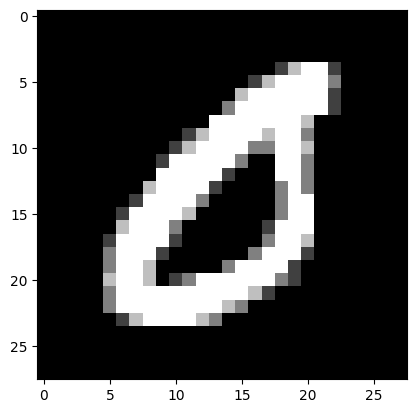

    0


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{labels[j]:5d}' for j in range(batch_size)))

In [9]:
from utils.config import device

net = arch(len(classes)).to(device)

In [10]:
net.q1.qc.qc.draw(style="clifford")

┌───────────────┐ ░ ┌─────────────────┐                »
   q_0: ┤ Rx(inputs[0]) ├─░─┤0                ├─■──────────────»
        ├───────────────┤ ░ │  Rxx(params[0]) │ │ZZ(params[1]) »
   q_1: ┤ Rx(inputs[1]) ├─░─┤1                ├─■──────────────»
        ├───────────────┤ ░ └─────────────────┘                »
   q_2: ┤ Rx(inputs[2]) ├─░────────────────────────────────────»
        └───────────────┘ ░                                    »
   c: 3/═══════════════════════════════════════════════════════»
                                                               »
meas: 3/═══════════════════════════════════════════════════════»
                                                               »
«                                           ┌─────────────────┐                »
«   q_0: ───────────────────────────────────┤1                ├─■──────────────»
«        ┌─────────────────┐                │                 │ │              »
«   q_1: ┤0                ├─■──────────────┤  Rxx(params[4]) ├─┼──────────────»
«        │  Rxx(params[2]) │ │ZZ(params[3]) │                 │ │ZZ(params[5]) »
«   q_2: ┤1                ├─■──────────────┤0                ├─■──────────────»
«        └─────────────────┘                └─────────────────┘                »
«   c: 3/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«meas: 3/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«         ░  ░ ┌─┐      
«   q_0: ─░──░─┤M├──────
«         ░  ░ └╥┘┌─┐   
«   q_1: ─░──░──╫─┤M├───
«         ░  ░  ║ └╥┘┌─┐
«   q_2: ─░──░──╫──╫─┤M├
«         ░  ░  ║  ║ └╥┘
«   c: 3/═══════╬══╬══╬═
«               ║  ║  ║ 
«meas: 3/═══════╩══╩══╩═
«               0  1  2

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

In [12]:
def val_acc(net):
    correct, total = 0, 0
    for i, data in enumerate(validloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = torch.argmax(net(inputs), dim = 1)
        correct += torch.sum(outputs == labels).item()

        total += 1

    return correct / batch_size / total

In [13]:
best_acc, best_epoch, best_model = 0, -1, arch(num_classes=len(classes))
history = []

def train(model, lr=0.002, epochs=15, teacher=None, print_every=10, verbose=True):
    global best_acc, best_model, history
    best_epoch = -1

    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    patience = 3
    for epoch in range(epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # labels = torch.tensor([1. if labels.item() == x else 0. for x in classes]).view(1, -1)

            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)

            if teacher is None:
                loss = criterion(outputs, labels) - 0.2 * torch.norm(model.q1.w)
            else:
                with torch.no_grad():
                    teacher_preds = torch.softmax(teacher(inputs).detach(), dim=1)
                    
                teaching_loss = criterion(outputs, teacher_preds)
                loss = criterion(outputs, labels) + teaching_loss - 0.2 * torch.norm(model.q1.w)
                    
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            
            
                
            # if i == batches: break
            if (i+1) % print_every == 0:
                if verbose:
                    print(f'[{epoch + 1}, {i+1}] loss: {running_loss / print_every:.3f}')
                    print(outputs[0], labels[0])
                # print(outputs[1], labels[1])
                with torch.no_grad():
                    acc = val_acc(model)
                
                if acc > best_acc:
                    best_acc = acc
                    best_epoch = epoch
                    best_model.load_state_dict(model.state_dict())

                history.append([running_loss / print_every, acc, outputs[0][0].item()])
                running_loss = 0.0
                if verbose:
                    print(f"Validation Accuracy: {acc:.3f}")

                

                if acc == 1: break
        if acc == 1: break

        if best_acc > 0.6 and epoch > best_epoch + patience: break
                
            

        # print(f'{epoch + 1} loss: {running_loss / n_samples:.3f}')
        # print(outputs[0], labels[0])
        # # print(outputs[1], labels[1])
        # with torch.no_grad():
        #     acc = val_acc(model)
        # print("Validation Accuracy:", acc)
        
        # if acc > best_acc:
        #     best_acc = acc
        #     best_batch = i
        #     best_model.load_state_dict(model.state_dict())

        # if i > best_batch + batch_patience: break

        # history.append([running_loss / n_samples, acc])
        
        # running_loss = 0.0


    print('Finished Training')
    return best_model, history

In [14]:
from models.cnet import SNet

TEACHER_PATH = './trained_models/clnet.pth'

teacher_arch = SNet
teacher = teacher_arch(len(classes))
teacher.load_state_dict(torch.load(TEACHER_PATH))
teacher = teacher.eval()

best_model, history = train(net, lr=0.002, teacher=teacher)

/Users/petergao/Documents/GitHub/Quantum/Digit-Classifier/qintegration/qmodule.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:277.)
  result = torch.tensor(values)


[1, 10] loss: 1.566
tensor([-0.1264,  0.4851], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 20] loss: 1.283
tensor([-0.1110,  0.4627], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 30] loss: 1.181
tensor([-0.1094,  0.4521], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 40] loss: 1.321
tensor([-0.1055,  0.4565], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 50] loss: 1.142
tensor([-0.1080,  0.4531], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 60] loss: 1.084
tensor([-0.1096,  0.4504], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 70] loss: 1.043
tensor([-0.1070,  0.4625], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 80] loss: 0.989
tensor([-0.1166,  0.4698], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 90] loss: 1.058
tensor([-0.1157,  0.4293], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[

KeyboardInterrupt: 

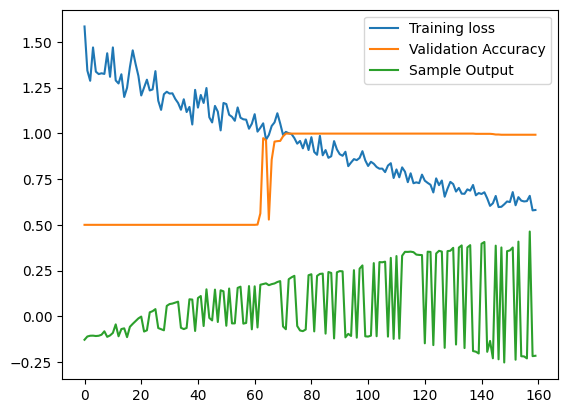

In [ ]:
plt.plot(history)
plt.legend(["Training loss", "Validation Accuracy", "Sample Output"])
plt.show()

In [ ]:
import copy

best_model, history = train(copy.deepcopy(best_model), lr=0.0005)

[1, 10] loss: 0.279
tensor([-0.0734,  0.4101], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.999
[1, 20] loss: 0.368
tensor([0.2027, 0.1375], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 30] loss: 0.260
tensor([0.2012, 0.1388], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 40] loss: 0.276
tensor([-0.0786,  0.4143], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.999
[1, 50] loss: 0.295
tensor([0.2005, 0.1406], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 60] loss: 0.315
tensor([0.2017, 0.1368], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 70] loss: 0.295
tensor([-0.0760,  0.4103], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.999
[1, 80] loss: 0.294
tensor([0.2024, 0.1302], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 90] loss: 0.313
tensor([0.2004, 0.1415], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.999
[1, 100] loss

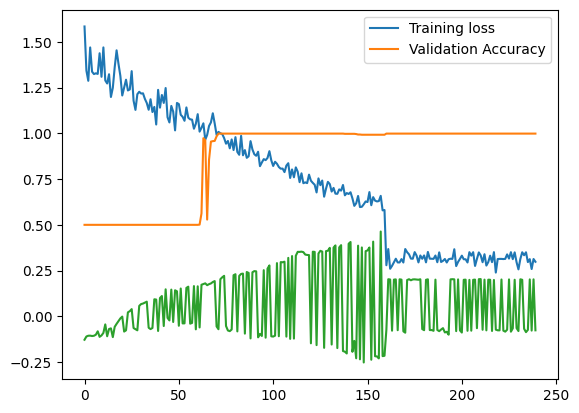

In [ ]:
plt.plot(history)
plt.legend(["Training loss", "Validation Accuracy"])
plt.show()

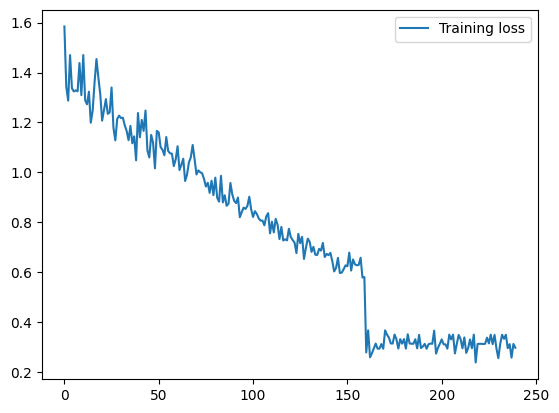

In [ ]:
plt.plot([x[0] for x in history])
plt.legend(["Training loss"])
plt.show()

In [ ]:
PATH = './trained_models/qnet.pth'
torch.save(best_model.state_dict(), PATH)

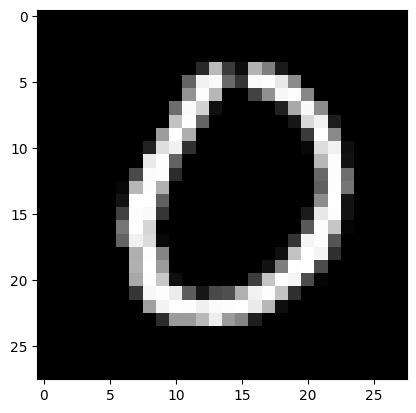

GroundTruth:      0


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{labels[j]:5d}' for j in range(batch_size)))

In [ ]:
net = arch(len(classes))
net.load_state_dict(torch.load(PATH))
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{predicted[j]:5d}'
                              for j in range(batch_size)))

Predicted:      0


In [ ]:
errors = []

correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(len(predicted)):
            if labels[i] != predicted[i]:
                errors.append(images[i])

print(f'Accuracy of the network on the test images with quantum layer: {100 * correct / total} %')

Accuracy of the network on the test images with quantum layer: 99.55074207781789 %


Incorrectly predicted images


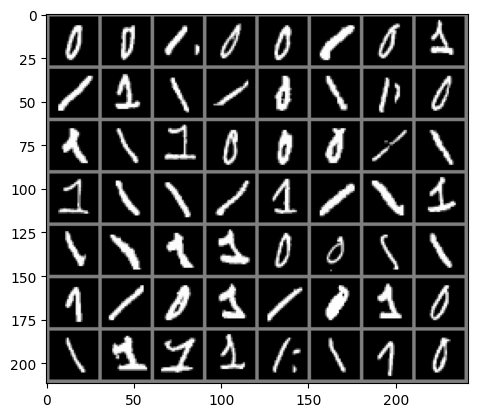

In [ ]:
print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[label.item()] += 1
            total_pred[label.item()] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Recall for class: {classname:5d} is {accuracy:.1f} %')

Recall for class:     0 is 99.7 %
Recall for class:     1 is 99.4 %


In [ ]:
print(net.q1.w)
net.q1.w = nn.Parameter(torch.zeros(net.q1.w.shape))

Parameter containing:
tensor([ 9.2814e-04, -1.5622e+00,  4.8536e-02,  1.2371e+00, -5.0156e-01,
         1.5474e+00], requires_grad=True)


In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images without quantum layer: {100 * correct / total} %')

Accuracy of the network on the test images without quantum layer: 99.53469715202567 %


# Training an ensemble

In [ ]:
# for i in range(5):
#     acc = 0
#     # only allow accuracy models
#     while acc < .9:
#         model, _ = train(arch(), verbose=False)
#         with torch.no_grad():
#             acc = val_acc(model)
#             print(i, acc)

#     PATH = f'./trained_models/qnet{i}.pth'
#     torch.save(model.state_dict(), PATH)
#     print(f"Finished model {i}")